# DeepLabCut Hackathon 2026 — Demo Notebook

This notebook is a hands-on guide for the **Lemanic Life Sciences Hackathon 2026** working with [DeepLabCut](https://github.com/DeepLabCut/DeepLabCut). It is split into two sections:

1. **Benchmarking DeepLabCut models** — How to train and evaluate pose-estimation and detection models using the hackathon benchmarking utilities, and how to visualize results.
2. **Extending DeepLabCut with External Detectors** — A primer on `deeplabcut.pose_estimation_pytorch.models.detectors.external`, the extension point we added for this hackathon.

> **Prerequisites** — Make sure you have installed this repository (`pip install -e .`) and the hackathon DLC fork (`pip install -e '.[dlc-mod]'`). A GPU is required for training; evaluation and visualization can run on CPU.

In [4]:
# This is just to verify that you installed the DLC-MOD with external detectors
import importlib.util

if importlib.util.find_spec("deeplabcut.pose_estimation_pytorch.models.detectors.external") is None:
    print(
        "Could not find DeepLabCut external detectors. "
        "You probably have not installed the DeepLabCut MOD for the Hackathon. "
        "Please install it by running:\n"
        "pip install -e '.[dlc-mod]'\n"
        "or\n"
        "pip install -e <path-to-your-dlc-mod-repo>"
    )

In [ ]:
import logging

import deeplabcut.pose_estimation_pytorch as dlc_torch

from dlc_hackathon.evaluation import (
    evaluate_detector,
    evaluate_pose_estimation,
    get_ground_truth_bboxes,
    get_ground_truth_poses,
    get_predicted_poses,
)
from dlc_hackathon.paths import CONFIGS_DIR
from dlc_hackathon.schemas.benchmarking import BenchMarkEvalConfig, BenchMarkTrainConfig
from dlc_hackathon.training import prepare_train_shuffle
from dlc_hackathon.visualization import (
    compare_metrics,
    metrics_summary_table,
    plot_bbox_entry,
    plot_pose_prediction,
)

logging.basicConfig(level=logging.INFO)

## Section 1: Benchmarking DeepLabCut Models

In this hackathon, we use the DeepLabCut **top-down** pose estimation pipeline for multi-animal projects:

1. A **detector** finds bounding boxes around each animal in the frame.
2. A **pose estimator** predicts keypoints within each bounding box.

This repository provides benchmarking utilities that wrap the DeepLabCut PyTorch API so you can train, evaluate, and compare models with structured YAML configs. The two model types you can train are `pose_estimation` and `detection`.

### Training

#### Configuration

Every training run is described by a `BenchMarkTrainConfig` (Pydantic model). It bundles:

| Field | Purpose |
|---|---|
| `dataset` | Which DLC project to use (`root`, `shuffle`, `trainsetindex`) |
| `model` | Architecture and model type (`type`: `pose_estimation` or `detection`. `net_type`: the DeepLabCut model architecture) |
| `train_settings` | Batch size, epochs, seed, etc. |
| `logger` | Weights & Biases logging configuration |
| `overrides` *(optional)* | Override default DLC data augmentation or optimizer/scheduler settings |

Configs are loaded from YAML — see `configs/example_train_pose.yaml` and `configs/example_train_detector.yaml` for full examples.

In [3]:
train_cfg = BenchMarkTrainConfig.from_yaml(CONFIGS_DIR / "example_train_pose.yaml")

print(f"Dataset:       {train_cfg.dataset.name}  (root: {train_cfg.dataset.root})")
print(f"Model:         {train_cfg.model.name}  (type: {train_cfg.model.type.value})")
print(f"Architecture:  {train_cfg.model.net_type}")
print(f"Shuffle:       {train_cfg.model.shuffle}")
print(f"Epochs:        {train_cfg.train_settings.epochs}")
print(f"Batch size:    {train_cfg.train_settings.batch_size}")
print(f"Overrides:     {'yes' if train_cfg.overrides else 'none (using DLC defaults)'}")

Dataset:       fish-benchmark  (root: /home/jaap/Projects/DLC-Hackaton-2026/data/fish-dlc-2021-05-07)
Model:         fish-pose-example  (type: pose_estimation)
Architecture:  top_down_rtmpose_m
Shuffle:       10
Epochs:        300
Batch size:    16
Overrides:     none (using DLC defaults)


#### Creating a training "shuffle"

Each training run in a DeepLabCut project is represented as a **shuffle**. Key things to know:

- A shuffle = 1 training run with a specific model, dataset split, and hyperparameters.
- Shuffles live inside the dataset root directory under `dlc-models-pytorch/`.
- `prepare_train_shuffle` creates a shuffle from a `BenchMarkTrainConfig`: it uses a fixed dataset split (from the source shuffle) and writes all parameters — including any `overrides` — into the DeepLabCut `pytorch_config.yaml`.

If the shuffle already exists, this is a no-op.

In [ ]:
# Prepare training data
prepare_train_shuffle(train_cfg)

Utilizing the following graph: [[0, 1], [0, 2], [0, 3], [0, 4], [0, 5], [0, 6], [1, 2], [1, 3], [1, 4], [1, 5], [1, 6], [2, 3], [2, 4], [2, 5], [2, 6], [3, 4], [3, 5], [3, 6], [4, 5], [4, 6], [5, 6]]
You passed a split with the following fraction: 70%
Creating training data for: Shuffle: 10 TrainFraction:  0.7


100%|██████████| 49/49 [00:00<00:00, 1211.03it/s]

The training dataset is successfully created. Use the function 'train_network' to start training. Happy training!


PosixPath('/home/jaap/Projects/DLC-Hackaton-2026/data/fish-dlc-2021-05-07/dlc-models-pytorch/iteration-0/fishMay7-trainset70shuffle10/train/pytorch_config.yaml')

#### Start training

After initializing a shuffle, call `train_model` to start training. Under the hood this fixes the random seed and calls `dlc_torch.train` with the correct task type.

> **Note:** Training is GPU-intensive and takes a while. The cell below is **commented out** so the notebook stays runnable without waiting for training.

In [ ]:
# Uncomment to train (requires GPU, takes a while)
# train_model(train_cfg, device="cuda")

### Evaluation

Evaluation mirrors training: it is driven by a `BenchMarkEvalConfig` loaded from YAML. The config points to the same dataset and the shuffle you trained.

For top-down models, evaluation has two stages:
1. **Detector evaluation** — How well does the detector find bounding boxes? Metrics: mAP, mAR at various IoU thresholds.
2. **Pose estimation evaluation** — How accurate are the predicted keypoints? Metrics: RMSE, mAP, mAR, and per-keypoint breakdowns.

You can evaluate the pose estimator with **ground-truth bounding boxes** (to isolate pose model quality) or with **predicted bounding boxes** (end-to-end performance).

In [4]:
eval_cfg = BenchMarkEvalConfig.from_yaml(CONFIGS_DIR / "example_eval_pose.yaml")

print(f"Dataset:       {eval_cfg.dataset.name}")
print(f"Model:         {eval_cfg.model.name}  (type: {eval_cfg.model.type.value})")
print(f"Architecture:  {eval_cfg.model.net_type}")
print(f"Shuffle:       {eval_cfg.model.shuffle}")

Dataset:       fish-benchmark
Model:         fish-pose-example  (type: pose_estimation)
Architecture:  top_down_rtmpose_m
Shuffle:       10


#### Detector evaluation

`evaluate_detector` loads the best detector snapshot, runs inference on train/test images, and computes bounding-box metrics (mAP, mAR) against the ground truth. It returns the predicted bounding boxes (which we can reuse for pose evaluation) and the metrics dict.

In [ ]:
# Pretrained detector
eval_cfg = BenchMarkEvalConfig.from_yaml(CONFIGS_DIR / "example_eval_detector.yaml")

bboxes, bbox_metrics = evaluate_detector(eval_cfg, device="cuda", use_cache=False)
bbox_metrics["test"]

{'mAP_50_95': 53.198981867494446,
 'mAP_50': 86.6191919952275,
 'mAP_75': 62.70158312185181,
 'mAR_50_95': 58.38596491228072,
 'mAR_50': 87.71929824561403,
 'mAR_75': 68.77192982456141,
 'mean_iou_matched_50': 0.8089207801818847,
 'num_images': 21,
 'num_gt_boxes': 285,
 'num_pred_boxes': 294}

#### Pose estimation evaluation

We evaluate the pose estimator in two modes to understand where errors come from:

1. **With ground-truth bounding boxes** — isolates the pose model's accuracy by removing detector noise.
2. **With predicted bounding boxes** — measures true end-to-end performance.

In [ ]:
# Mode 1: ground-truth bboxes (isolate pose model quality)
eval_cfg = BenchMarkEvalConfig.from_yaml("configs/example_eval_pose.yaml")

pose_metrics_gt = evaluate_pose_estimation(eval_cfg, bboxes=None, device="cuda")
pose_metrics_gt["test"]

{'rmse': 5.409287921070116,
 'rmse_pcutoff': 5.517308049240691,
 'mAP': 77.11558184983717,
 'mAR': 86.52482269503545,
 'rmse_detections': 4.894809722900391,
 'rmse_detections_pcutoff': 4.989800453186035}

In [9]:
# Mode 2: predicted bboxes (end-to-end performance)
pose_metrics_e2e = evaluate_pose_estimation(eval_cfg, bboxes=bboxes, device="cuda")
pose_metrics_e2e["test"]

{'rmse': 6.2358480152751135,
 'rmse_pcutoff': 6.286028322091295,
 'mAP': 64.00239694575906,
 'mAR': 76.27659574468085,
 'rmse_detections': 8.309967994689941,
 'rmse_detections_pcutoff': 8.45508861541748}

### Visualizing Predictions

The `dlc_hackathon.visualization` module provides overlay helpers for bounding boxes and keypoints. Let's look at a test image to compare ground-truth annotations with model predictions.

#### Bounding box overlay: ground truth vs. predictions

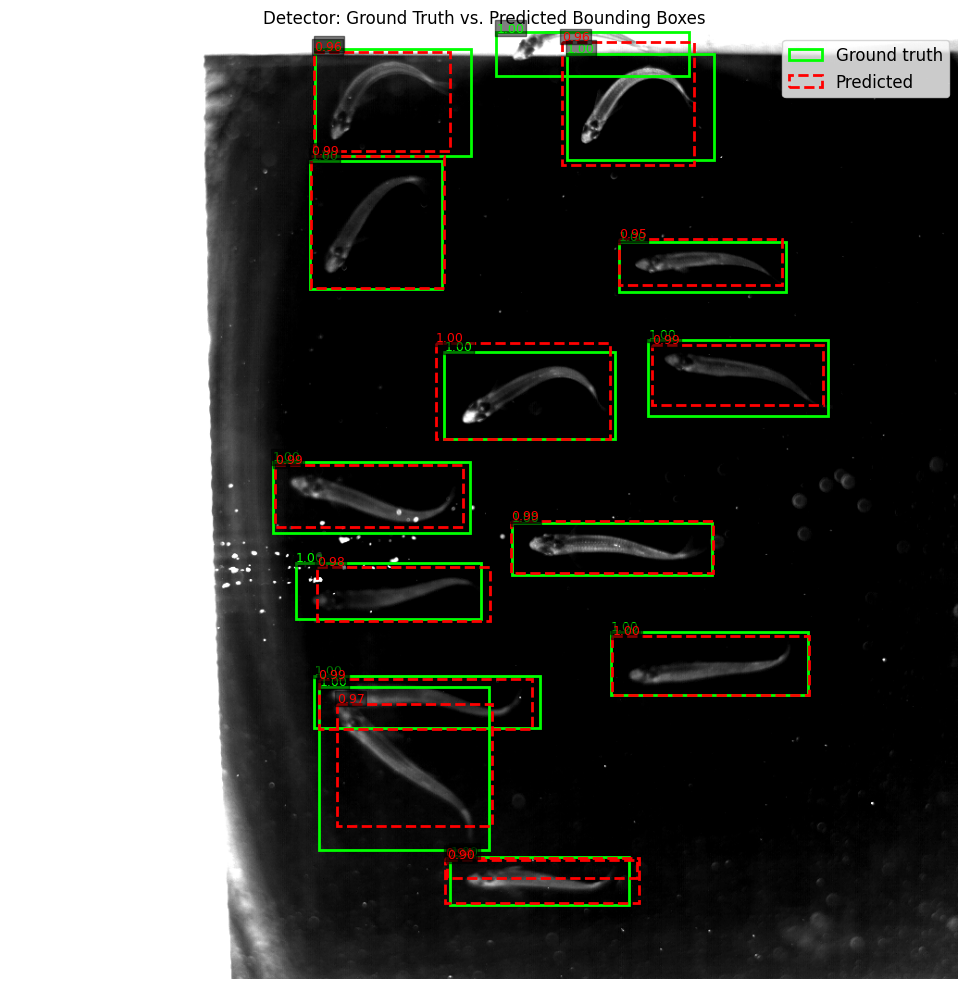

In [10]:
import matplotlib.pyplot as plt

loader = dlc_torch.DLCLoader(
    config=eval_cfg.dataset.project_config_path,
    shuffle=eval_cfg.model.shuffle,
    trainset_index=eval_cfg.model.trainsetindex,
)
gt_bboxes = get_ground_truth_bboxes(loader)

IMAGE_IDX = 0

fig, ax = plt.subplots(figsize=(14, 10))
image = plt.imread(gt_bboxes.test[IMAGE_IDX].image_path)
ax.imshow(image)
plot_bbox_entry(
    gt_bboxes.test[IMAGE_IDX],
    ax=ax,
    color="lime",
    linewidth=2,
    label="Ground truth",
)
plot_bbox_entry(
    bboxes.test[IMAGE_IDX],
    ax=ax,
    color="red",
    linewidth=2,
    linestyle="--",
    show_image=False,
    show_scores=True,
    label="Predicted",
)
ax.legend(fontsize=12)
ax.set_title("Detector: Ground Truth vs. Predicted Bounding Boxes")
ax.axis("off")
plt.tight_layout()

#### Keypoint overlay: ground truth vs. predictions

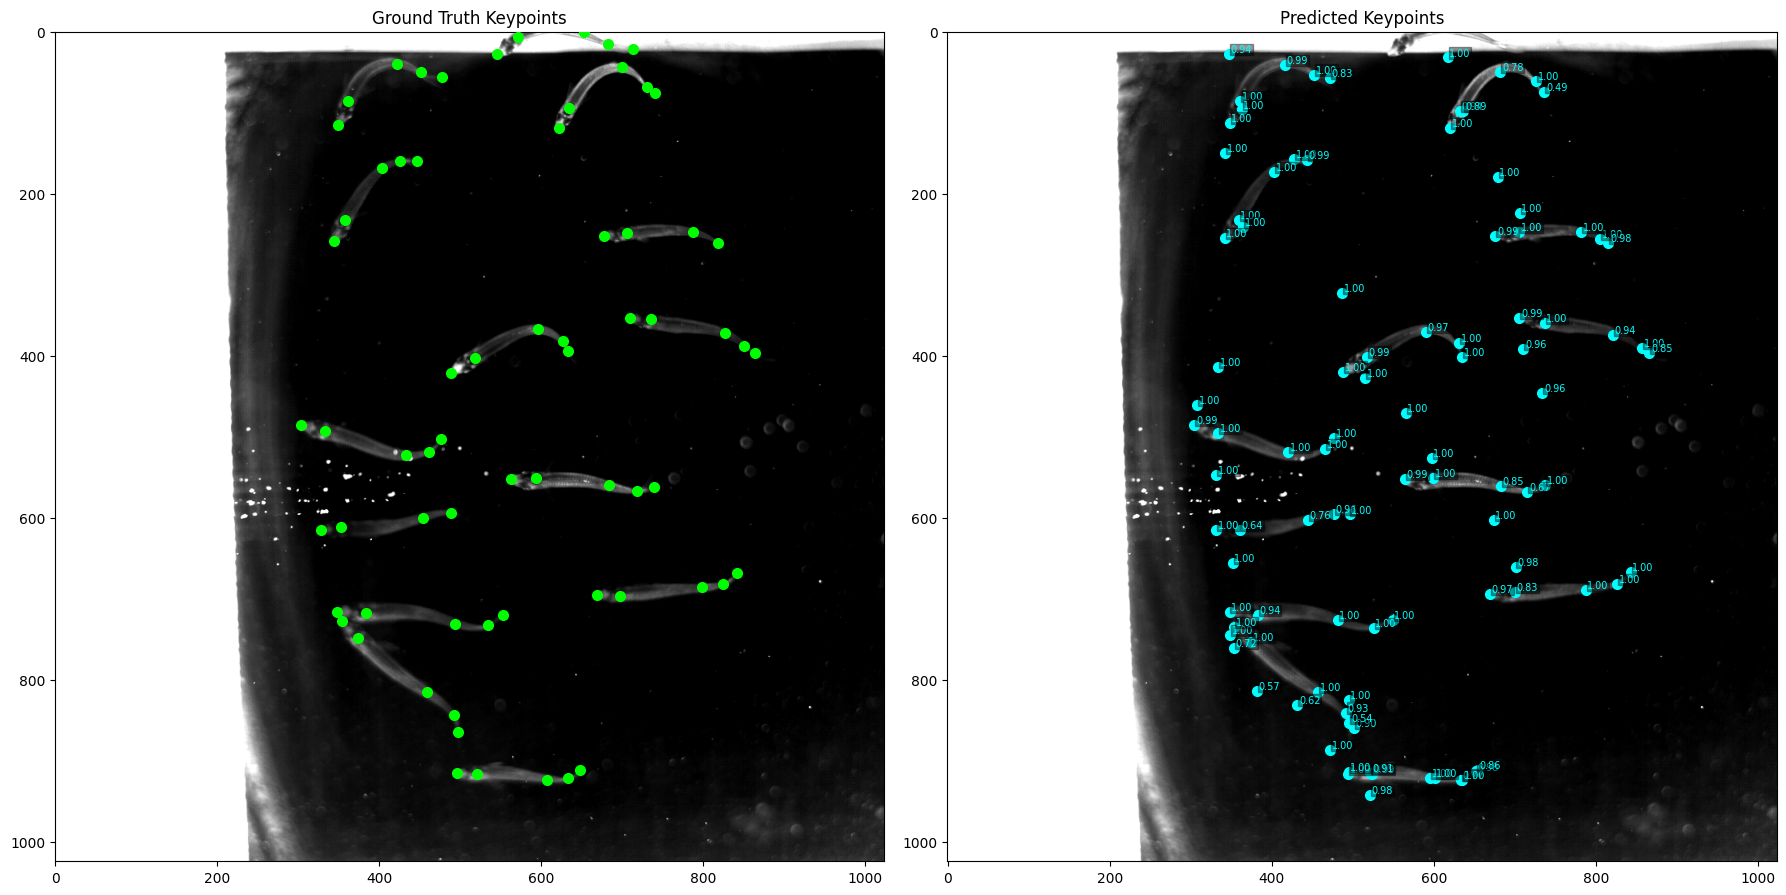

In [12]:
gt_poses = get_ground_truth_poses(loader)
pred_poses = get_predicted_poses(loader, bboxes, device="cuda")

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
image = plt.imread(gt_bboxes.test[IMAGE_IDX].image_path)
axes[0].imshow(image)
axes[1].imshow(image)
plot_pose_prediction(
    gt_poses.test[IMAGE_IDX],
    ax=axes[0],
    color="lime",
    marker_size=7,
    score_threshold=0.0,
    label="Ground truth",
)
axes[0].set_title("Ground Truth Keypoints")

plot_pose_prediction(
    pred_poses.test[IMAGE_IDX],
    ax=axes[1],
    color="cyan",
    marker_size=7,
    score_threshold=0.3,
    show_scores=True,
    label="Predicted",
)
axes[1].set_title("Predicted Keypoints")

plt.tight_layout()

### Comparing Runs

After evaluating multiple models (or the same model under different conditions), you can compare their metrics side-by-side using `compare_metrics` (grouped bar chart) and `metrics_summary_table` (pandas DataFrame).

Below we compare the pose estimator evaluated with ground-truth bounding boxes vs. predicted bounding boxes — this shows how much detector quality affects the final pose accuracy.

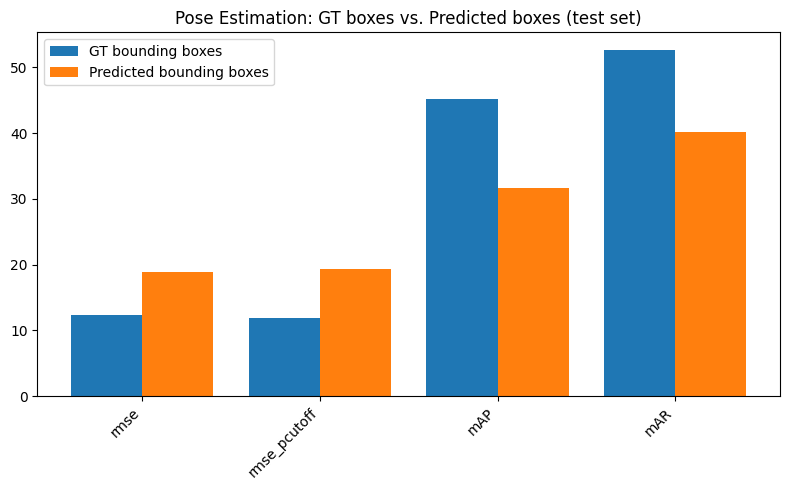

In [13]:
fake_pose_metrics_gt = {
    "rmse": 12.4,
    "rmse_pcutoff": 11.8,
    "mAP": 45.2,
    "mAR": 52.7,
    "rmse_detections": 13.1,
    "rmse_detections_pcutoff": 12.5,
}
fake_pose_metrics_e2e = {
    "rmse": 18.9,
    "rmse_pcutoff": 19.3,
    "mAP": 31.6,
    "mAR": 40.1,
    "rmse_detections": 21.0,
    "rmse_detections_pcutoff": 20.4,
}

runs = {
    "GT bounding boxes": fake_pose_metrics_gt,
    "Predicted bounding boxes": fake_pose_metrics_e2e,
}

fig, ax = compare_metrics(
    runs,
    metrics=["rmse", "rmse_pcutoff", "mAP", "mAR"],
    title="Pose Estimation: GT boxes vs. Predicted boxes (test set)",
)
plt.show()

In [14]:
metrics_summary_table(runs)

,rmse,rmse_pcutoff,mAP,mAR,rmse_detections,rmse_detections_pcutoff
GT bounding boxes,12.4,11.8,45.2,52.7,13.1,12.5
Predicted bounding boxes,18.9,19.3,31.6,40.1,21.0,20.4


### Saving & Loading Metrics

You can persist metrics to JSON for later comparison (e.g. across different notebooks or experiment sessions).

In [ ]:
# Save metrics:
# save_metrics(pose_metrics_e2e, RESULTS_DIR / "example_pose_metrics.json")
# save_metrics(bbox_metrics, RESULTS_DIR / "example_bbox_metrics.json")

# Reload later:
# loaded = load_metrics(Path("results/example_pose_metrics.json"))
# loaded["test"]

---

## Section 2: Extending DeepLabCut with External Detectors

*Coming next...*